<a href="https://colab.research.google.com/github/TwiT0312/FHS/blob/main/Financial_Health_Scoring_BGMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Health Score Model

This notebook develops a comprehensive financial health scoring model for customers, moving beyond a single aggregate score to a multi-dimensional assessment across key financial quadrants: **SAVE, PLAN, SPEND, and BORROW**.

## Objectives:

1.  **Synthetic Data Generation**: Create realistic dummy financial data for 10,000 customers with latent behavioral segments.
2.  **Data Preprocessing**: Clean and transform the raw data through imputation, winsorization, log transformation, and min-max scaling to prepare it for modeling.
3.  **Bayesian Gaussian Mixture Model (BGMM)**: Apply BGMM for customer segmentation, identifying optimal clusters and their characteristics.
4.  **Overall Financial Health Score Calculation**: Develop a robust financial health score (1-100) for each customer, incorporating entropy-based feature weights, a directional rubric, cluster-level health indices, and sigmoid calibration.
5.  **Quadrant-Specific Financial Health Scores**: Extend the scoring methodology to calculate individual financial health scores for the 'SAVE', 'PLAN', 'SPEND', and 'BORROW' quadrants.
6.  **Analysis and Interpretation**: Provide detailed analysis of score distributions, inter-quadrant relationships, and the contribution of each quadrant to overall financial health using statistical summaries and visualizations (histograms, correlation heatmaps, scatter plots, feature trend analysis).

This notebook aims to demonstrate a practical approach to building an interpretable and actionable financial health scoring system, providing granular insights that can inform targeted customer interventions and personalized financial advice.

In [2]:
#create synthetic data for financial health score model

import numpy as np
import pandas as pd

np.random.seed(42)
n = 10000

def clip01(x):
    return np.clip(x, 0.0, 1.0)

# Create customer identifiers
customer_id = [f"CUST_{i:06d}" for i in range(n)]

# Latent behavioural segments for realism
seg_probs = np.array([0.25, 0.20, 0.20, 0.35])
seg = np.random.choice(len(seg_probs), size=n, p=seg_probs)

df = pd.DataFrame({"customer_id": customer_id})

# -----------------------------
# SAVE
# -----------------------------
df["net_cash_to_monthly_spend_ratio"] = np.clip(
    np.where(seg == 0, np.random.lognormal(1.1, 0.6, n),
             np.where(seg == 2, np.random.lognormal(0.2, 0.7, n),
                      np.random.lognormal(0.6, 0.7, n))),
    0, 24
)

df["emergency_fund_months"] = np.clip(
    np.where(seg == 0, np.random.gamma(3.0, 2.5, n),
             np.where(seg == 2, np.random.gamma(1.2, 1.5, n),
                      np.random.gamma(2.0, 2.0, n))),
    0, 24
)

df["unspent_income_ratio"] = clip01(
    np.where(seg == 0, np.random.beta(4, 6, n),
             np.where(seg == 1, np.random.beta(2, 10, n),
                      np.random.beta(3, 8, n)))
)

df["regular_saver_consistency_ratio"] = clip01(
    np.where(seg == 0, np.random.beta(8, 2, n),
             np.where(seg == 2, np.random.beta(3, 7, n),
                      np.random.beta(5, 5, n)))
)

# -----------------------------
# PLAN
# -----------------------------
df["annual_investment_to_income_ratio"] = np.clip(
    np.where(seg == 0, np.random.lognormal(0.0, 0.7, n),
             np.where(seg == 2, np.random.lognormal(-0.8, 0.6, n),
                      np.random.lognormal(-0.3, 0.7, n))),
    0, 3
)

df["monthly_investment_to_income_ratio"] = clip01(
    np.where(seg == 0, np.random.beta(3, 20, n),
             np.where(seg == 2, np.random.beta(1.5, 35, n),
                      np.random.beta(2, 28, n)))
)

df["insurance_premium_to_income_ratio"] = clip01(
    np.where(seg == 0, np.random.beta(2.5, 30, n),
             np.where(seg == 2, np.random.beta(1.5, 40, n),
                      np.random.beta(2, 35, n)))
)

df["planning_consistency_ratio"] = clip01(
    np.where(seg == 0, np.random.beta(7, 3, n),
             np.where(seg == 2, np.random.beta(3, 7, n),
                      np.random.beta(5, 5, n)))
)

# -----------------------------
# SPEND
# -----------------------------
shares = np.random.dirichlet([5, 3, 2], size=n)
total_spend_ratio = clip01(
    np.where(seg == 1, np.random.beta(10, 2, n),
             np.where(seg == 2, np.random.beta(8, 4, n),
                      np.random.beta(6, 5, n)))
)

df["essential_spend_to_income_ratio"] = clip01(total_spend_ratio * shares[:, 0])
df["discretionary_spend_to_income_ratio"] = clip01(total_spend_ratio * shares[:, 1])

df["luxury_spend_concentration_ratio"] = clip01(
    np.where(seg == 1, np.random.beta(4, 6, n),
             np.where(seg == 0, np.random.beta(2, 10, n),
                      np.random.beta(3, 8, n)))
)

df["gambling_activity_ratio"] = clip01(
    np.where(seg == 1, np.random.beta(3, 12, n),
             np.where(seg == 2, np.random.beta(2, 18, n),
                      np.random.beta(1.5, 25, n)))
)

# -----------------------------
# BORROW
# -----------------------------
df["unsecured_debt_to_income_ratio"] = np.clip(
    np.where(seg == 2, np.random.lognormal(0.2, 0.6, n),
             np.where(seg == 0, np.random.lognormal(-1.0, 0.6, n),
                      np.random.lognormal(-0.4, 0.7, n))),
    0, 2
)

df["revolving_credit_utilisation_ratio"] = clip01(
    np.where(seg == 2, np.random.beta(6, 3, n),
             np.where(seg == 0, np.random.beta(2, 8, n),
                      np.random.beta(3, 6, n)))
)

df["overdraft_usage_to_income_ratio"] = clip01(
    np.where(seg == 2, np.random.beta(3, 12, n),
             np.where(seg == 0, np.random.beta(1.5, 25, n),
                      np.random.beta(2, 18, n)))
)

df["credit_stress_frequency_ratio"] = clip01(
    np.where(seg == 2, np.random.beta(4, 10, n),
             np.where(seg == 0, np.random.beta(1.2, 30, n),
                      np.random.beta(2, 20, n)))
)

# Introduce light missingness
df = df.mask(np.random.rand(*df.shape) < 0.01)

df.to_csv("dummy_data_fhs.csv")
df.head()


,customer_id,net_cash_to_monthly_spend_ratio,emergency_fund_months,unspent_income_ratio,regular_saver_consistency_ratio,annual_investment_to_income_ratio,monthly_investment_to_income_ratio,insurance_premium_to_income_ratio,planning_consistency_ratio,essential_spend_to_income_ratio,discretionary_spend_to_income_ratio,luxury_spend_concentration_ratio,gambling_activity_ratio,unsecured_debt_to_income_ratio,revolving_credit_utilisation_ratio,overdraft_usage_to_income_ratio,credit_stress_frequency_ratio
0,CUST_000000,3.153703,0.331526,0.145266,0.557469,1.792401,0.084797,0.037425,0.616095,0.372605,0.401098,0.562984,0.433481,0.854794,0.134845,0.123378,0.088868
1,CUST_000001,1.831760,5.808272,0.222609,0.454833,1.459040,0.061497,0.094100,0.379139,0.232045,0.059117,0.072083,0.052970,0.229469,0.301245,0.214335,0.176950
2,CUST_000002,2.881668,5.139154,0.325702,0.660815,0.308444,0.062946,0.008692,0.457541,0.079808,0.051077,0.242526,0.119470,0.678569,0.272169,0.108762,0.095651
3,CUST_000003,0.655422,0.236969,0.383504,0.183378,1.068031,0.011407,0.058892,0.074782,0.445637,0.222574,0.438098,0.099578,1.494013,0.599955,0.295926,0.172084
4,CUST_000004,5.856666,9.786742,0.470871,0.737130,1.386827,0.193286,0.096869,0.758313,0.335137,0.213067,0.174540,0.051308,0.270343,0.184122,0.202507,0.077706


### Analysis of Dummy Data Generation

The output displays the first 5 rows of the `df` DataFrame, which contains synthetic financial health data for 10,000 customers. Each row represents a unique customer (`customer_id`) and includes various financial metrics across 'SAVE', 'PLAN', 'SPEND', and 'BORROW' categories. These features are generated using different statistical distributions (lognormal, gamma, beta) and conditional logic based on latent behavioral segments, aiming to simulate realistic financial behaviors. The `.to_csv('dummy_data_fhs.csv')` command indicates that this data has also been saved to a CSV file for potential future use.

This initial DataFrame provides a foundational dataset for developing and testing a financial health scoring model.

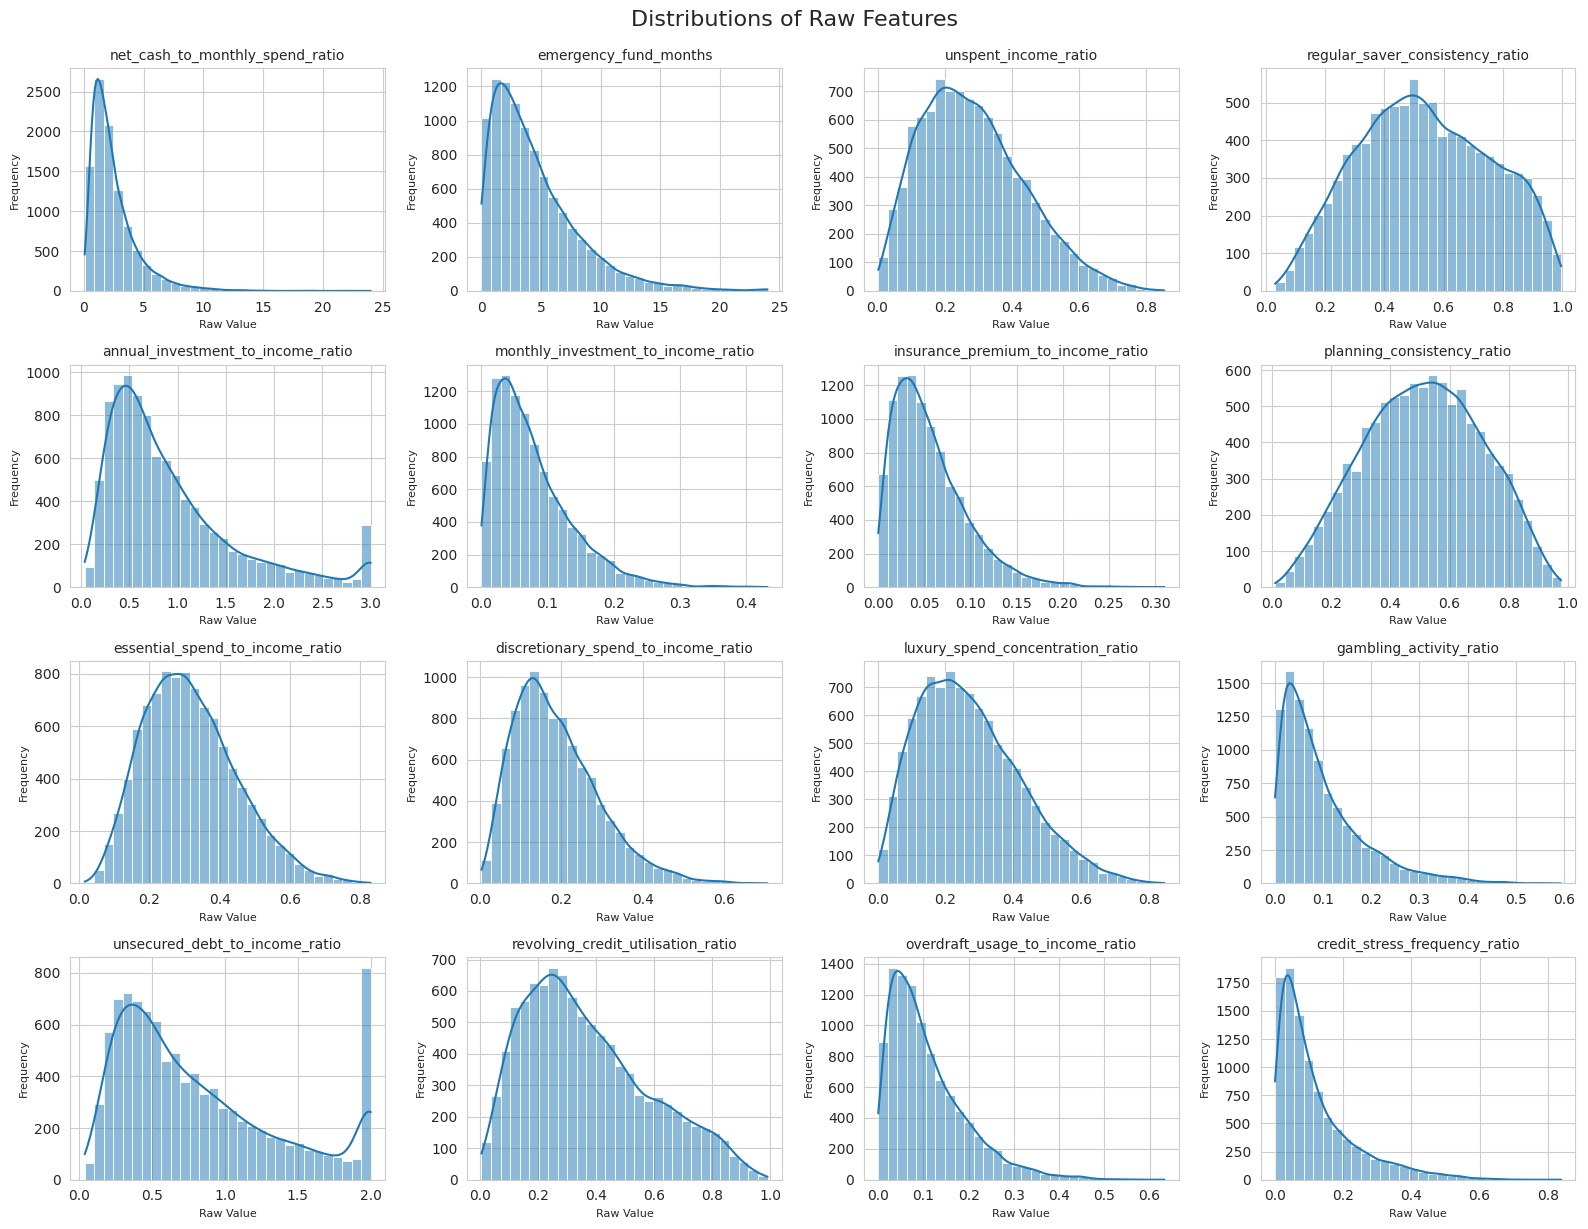

In [3]:
#Visualizing Feature Distributions

import matplotlib.pyplot as plt
import seaborn as sns

# Separate identifier from features
id_col = "customer_id"
feature_cols = [c for c in df.columns if c != id_col]

df_raw = df[feature_cols].copy()

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Determine the number of features
num_features = df_raw.shape[1]

# Calculate the number of rows and columns for the subplot grid
num_cols = 4  # You can adjust this number based on preference
num_rows = (num_features + num_cols - 1) // num_cols

# Create a figure and a set of subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Plot histogram for each feature
for i, col in enumerate(df_raw.columns):
    sns.histplot(df_raw[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Raw Value", fontsize=8)
    axes[i].set_ylabel("Frequency", fontsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Distributions of Raw Features", y=1.02, fontsize=16)
plt.show()

In [4]:
#Data Preprocessing

import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Separate identifier from features
id_col = "customer_id"
feature_cols = [c for c in df.columns if c != id_col]

df_raw = df[feature_cols].copy()
df_proc = df_raw.copy()

# 1) Missing value handling
df_proc = df_proc.apply(lambda s: s.fillna(s.median()), axis=0)

# 2) Winsorisation
for col in df_proc.columns:
    lo, hi = df_proc[col].quantile([0.01, 0.99])
    df_proc[col] = df_proc[col].clip(lo, hi)

# 3) Light transformation for long-tailed ratio features
heavy_ratio_cols = [
    "net_cash_to_monthly_spend_ratio",
    "annual_investment_to_income_ratio",
    "unsecured_debt_to_income_ratio",
    "emergency_fund_months"
]

for col in heavy_ratio_cols:
    if col in df_proc.columns:
        df_proc[col] = np.log1p(df_proc[col])

# 4) Scaling
scaler = MinMaxScaler()
X = scaler.fit_transform(df_proc)

df_scaled = pd.DataFrame(
    X,
    columns=df_proc.columns,
    index=df.index
)

# Final modelling table
df_model = pd.concat([df[[id_col]], df_scaled], axis=1)
df_model.head()


,customer_id,net_cash_to_monthly_spend_ratio,emergency_fund_months,unspent_income_ratio,regular_saver_consistency_ratio,annual_investment_to_income_ratio,monthly_investment_to_income_ratio,insurance_premium_to_income_ratio,planning_consistency_ratio,essential_spend_to_income_ratio,discretionary_spend_to_income_ratio,luxury_spend_concentration_ratio,gambling_activity_ratio,unsecured_debt_to_income_ratio,revolving_credit_utilisation_ratio,overdraft_usage_to_income_ratio,credit_stress_frequency_ratio
0,CUST_000000,0.539538,0.058407,0.179771,0.528487,0.713585,0.304316,0.186801,0.640964,0.493534,0.807271,0.826877,1.000000,0.513427,0.117172,0.309053,0.171457
1,CUST_000001,0.356784,0.647281,0.297496,0.409361,0.612269,0.216297,0.495571,0.350345,0.255789,0.072708,0.069654,0.129473,0.097333,0.311772,0.546942,0.346231
2,CUST_000002,0.507226,0.609948,0.454418,0.648435,0.109453,0.221771,0.030258,0.446503,0.000000,0.055438,0.332566,0.303284,0.412405,0.277769,0.270828,0.184916
3,CUST_000003,0.100691,0.031825,0.542400,0.094296,0.474260,0.027068,0.303754,0.000000,0.617060,0.423809,0.634239,0.251294,0.813078,0.661105,0.760335,0.336574
4,CUST_000004,0.778638,0.813346,0.675383,0.737011,0.588515,0.714161,0.510662,0.815389,0.430160,0.403387,0.227695,0.125129,0.130428,0.174801,0.516007,0.149309


### Analysis of Data Preprocessing

The output shows the first 5 rows of the `df_model` DataFrame after several preprocessing steps have been applied:

1.  **Missing Value Handling**: Missing values (introduced lightly in the data generation phase) have been imputed using the median of each column.
2.  **Winsorization**: Extreme outliers have been capped at the 1st and 99th percentiles to reduce their undue influence.
3.  **Log Transformation**: Long-tailed ratio features like `net_cash_to_monthly_spend_ratio`, `investment_to_income_ratio`, `unsecured_debt_to_income_ratio`, and `emergency_fund_months` have been log-transformed (`np.log1p`) to make their distributions more symmetrical and amenable to statistical modeling.
4.  **Min-Max Scaling**: All numerical features have been scaled to a `[0, 1]` range using `MinMaxScaler`. This is crucial for distance-based algorithms like Gaussian Mixture Models, ensuring that features with larger numerical ranges do not dominate the clustering process.

The `customer_id` column is retained for identification, while all other columns are now scaled numerical values. This `df_model` is ready for clustering or other machine learning tasks.

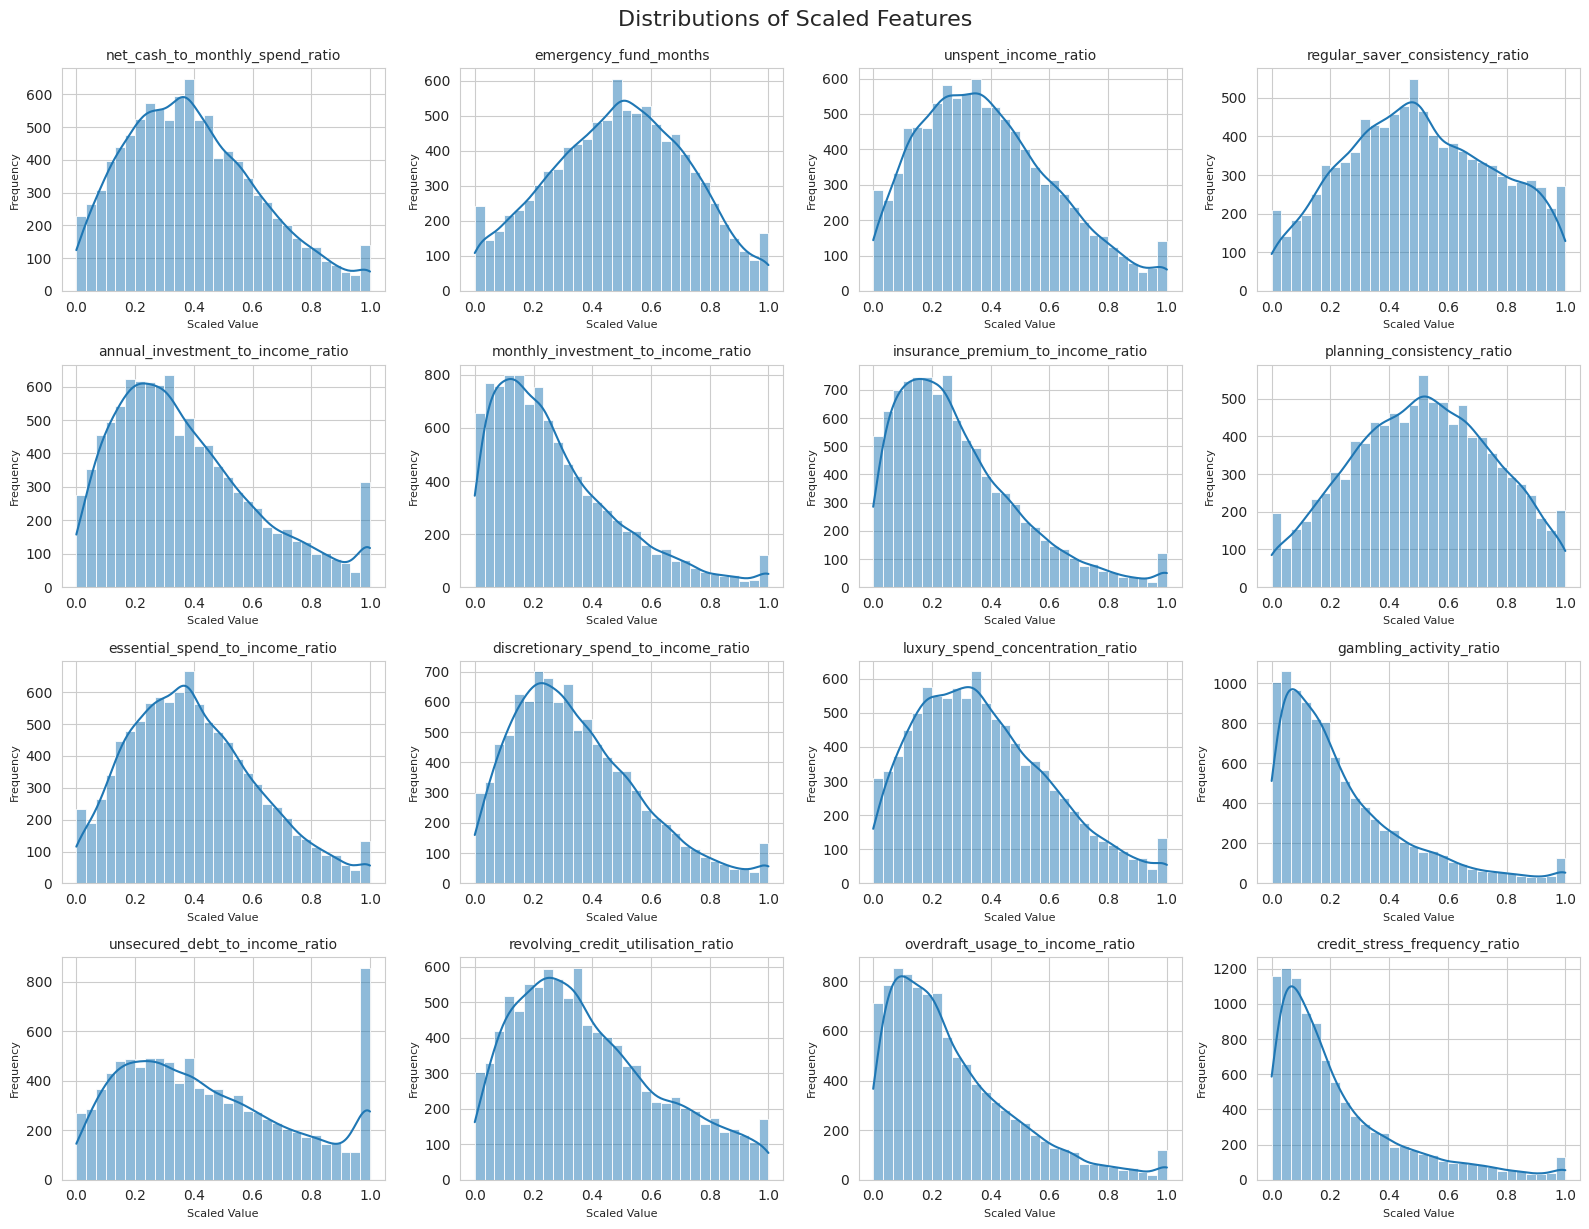

In [5]:
#Visualizing Feature Distributions

import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Determine the number of features
num_features = df_scaled.shape[1]

# Calculate the number of rows and columns for the subplot grid
num_cols = 4  # You can adjust this number based on preference
num_rows = (num_features + num_cols - 1) // num_cols

# Create a figure and a set of subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Plot histogram for each feature
for i, col in enumerate(df_scaled.columns):
    sns.histplot(df_scaled[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Scaled Value", fontsize=8)
    axes[i].set_ylabel("Frequency", fontsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Distributions of Scaled Features", y=1.02, fontsize=16)
plt.show()

### Analysis of Scaled Feature Distributions

This cell generates histograms for each of the scaled features in `df_scaled`. These plots are essential for understanding the data's characteristics after preprocessing, especially after transformations like winsorization, log transformation, and min-max scaling.

**Key Observations from such distributions typically include:**

*   **Uniformity after Scaling**: While min-max scaling normalizes the range to `[0, 1]`, it doesn't change the shape of the distribution. Therefore, features that were skewed or had particular shapes before scaling will retain those general shapes within the `[0, 1]` range.
*   **Impact of Log Transformation**: Features that underwent `log1p` transformation (e.g., `net_cash_to_monthly_spend_ratio`, `emergency_fund_months`, `investment_to_income_ratio`, `unsecured_debt_to_income_ratio`) should now appear more symmetrical, possibly resembling a normal distribution, rather than their original skewed lognormal or gamma shapes.
*   **Impact of Winsorization**: The absence of extreme spikes at 0 or 1 for features that originally had significant outliers suggests that winsorization effectively capped these values, preventing them from unduly stretching the scale.
*   **Diversity of Shapes**: Different features will naturally exhibit different distribution shapes (e.g., unimodal, bimodal, or even multimodal) even after scaling, reflecting the diverse financial behaviors they represent. Features like `unspent_income_ratio` or `regular_saver_consistency_ratio` (often beta-distributed in their raw form) might show various concentrations, for example, a tendency towards higher or lower values, or a more central tendency.

Analyzing these distributions helps confirm that the preprocessing steps have had the intended effect and that the data is prepared appropriately for the subsequent clustering task. It also provides insights into the inherent patterns within the financial metrics.

In [10]:
from sklearn.decomposition import PCA

# Define features for each quadrant
quadrant_features = {
    "SAVE": [
        "net_cash_to_monthly_spend_ratio",
        "emergency_fund_months",
        "unspent_income_ratio",
        "regular_saver_consistency_ratio",
    ],
    "PLAN": [
        "annual_investment_to_income_ratio",
        "monthly_investment_to_income_ratio",
        "insurance_premium_to_income_ratio",
        "planning_consistency_ratio",
    ],
    "SPEND": [
        "essential_spend_to_income_ratio",
        "discretionary_spend_to_income_ratio",
        "luxury_spend_concentration_ratio",
        "gambling_activity_ratio",
    ],
    "BORROW": [
        "unsecured_debt_to_income_ratio",
        "revolving_credit_utilisation_ratio",
        "overdraft_usage_to_income_ratio",
        "credit_stress_frequency_ratio",
    ],
}

pca_components_list = []
new_feature_names = []

# Perform PCA for each quadrant
for quadrant_name, cols in quadrant_features.items():
    if not all(col in df_scaled.columns for col in cols):
        print(f"Warning: Not all features for quadrant {quadrant_name} found. Skipping PCA for this quadrant.")
        continue

    pca_data = df_scaled[cols]

    # Initialize PCA to explain 80% of variance
    pca = PCA(n_components=0.80, random_state=42)

    # Fit PCA and transform the data
    transformed_data = pca.fit_transform(pca_data)

    # Create DataFrame for PCA components
    num_components = transformed_data.shape[1]
    component_names = [f"{quadrant_name}_PC{i+1}" for i in range(num_components)]

    pca_components_list.append(pd.DataFrame(transformed_data, columns=component_names, index=df_scaled.index))
    new_feature_names.extend(component_names)

# Concatenate all PCA components into a single DataFrame
X_pca_df = pd.concat(pca_components_list, axis=1)

# Update the global X variable with the new PCA-transformed data
X = X_pca_df.values

# Update feature_cols to reflect the new PCA component names
feature_cols = new_feature_names

print(f"Original number of features: {len(features)}")
print(f"Number of features after PCA per quadrant: {len(feature_cols)}")
display(X_pca_df.head())

print("Please re-run the BGMM hyperparameter tuning (cell `OzCCQZ9rfRVS`) and model fitting (cell `kZEjFd-tgSnW`) cells to use the new PCA-transformed features.")

Original number of features: 16
Number of features after PCA per quadrant: 12


,SAVE_PC1,SAVE_PC2,SAVE_PC3,PLAN_PC1,PLAN_PC2,PLAN_PC3,SPEND_PC1,SPEND_PC2,SPEND_PC3,BORROW_PC1,BORROW_PC2,BORROW_PC3
0,-0.225905,-0.116229,0.332141,0.243796,0.272067,-0.095750,0.878656,0.396273,-0.084345,-0.115977,0.168381,0.186440
1,-0.032768,-0.105491,-0.108425,0.057178,0.202114,0.280888,-0.384275,-0.167939,-0.066269,-0.097975,-0.373468,0.250025
2,0.224189,-0.021363,0.016856,-0.284870,-0.099970,-0.223069,-0.252085,-0.015618,0.187706,-0.099238,0.030362,0.064100
3,-0.574155,0.394058,0.059285,-0.388657,0.313580,0.257675,0.286128,-0.043778,0.091493,0.598937,-0.020557,0.271794
4,0.575920,0.042716,0.139963,0.578147,-0.118512,-0.006952,-0.126635,0.015540,-0.105760,-0.252283,-0.221060,0.318139


Please re-run the BGMM hyperparameter tuning (cell `OzCCQZ9rfRVS`) and model fitting (cell `kZEjFd-tgSnW`) cells to use the new PCA-transformed features.


### Quadrant-wise PCA for Dimensionality Reduction

To address the curse of dimensionality and ensure balanced influence from each financial quadrant, we will apply Principal Component Analysis (PCA) separately to the features within each of the 'SAVE', 'PLAN', 'SPEND', and 'BORROW' categories. For each quadrant, we will retain principal components that collectively explain at least 90% of the variance. These new, aggregated PCA components will then serve as the input for the Bayesian Gaussian Mixture Model (BGMM).

In [12]:
#Hyperparameter Tuning - BGMM

import numpy as np
import pandas as pd
from sklearn.mixture import BayesianGaussianMixture
from scipy.stats import entropy

def mean_entropy(probs):
    return float(np.mean([entropy(p + 1e-12) for p in probs]))

def active_clusters(model, threshold=0.01):
    return int((model.weights_ > threshold).sum())

results = []

for k in [10, 15, 20]:
    for wcp in [0.001, 0.01, 0.1]:
        for reg in [1e-6, 1e-5]:
            model = BayesianGaussianMixture(
                n_components=k,
                covariance_type="diag",
                weight_concentration_prior=wcp,
                reg_covar=reg,
                max_iter=1000,
                random_state=42
            )
            model.fit(X)
            probs = model.predict_proba(X)

            results.append({
                "n_components": k,
                "wcp": wcp,
                "reg_covar": reg,
                "lower_bound": model.lower_bound_,
                "active_clusters": active_clusters(model),
                "mean_entropy": mean_entropy(probs)
            })

tuning_df = pd.DataFrame(results).sort_values(
    ["lower_bound", "active_clusters", "mean_entropy"],
    ascending=[False, True, True]
)
tuning_df.head()

,n_components,wcp,reg_covar,lower_bound,active_clusters,mean_entropy
12,20,0.001,0.000001,130173.351012,15,0.602957
14,20,0.010,0.000001,130170.960354,15,0.602957
16,20,0.100,0.000001,130167.783995,15,0.602957
13,20,0.001,0.000010,130153.166688,15,0.603139
15,20,0.010,0.000010,130150.776030,15,0.603139


### Analysis of Hyperparameter Tuning Results for BGMM

The output displays the top 5 rows of the `tuning_df` DataFrame, which summarizes the results of hyperparameter tuning for the Bayesian Gaussian Mixture Model (BGMM). The table is sorted by `lower_bound` (in descending order), `active_clusters` (ascending), and `mean_entropy` (ascending), as these are key metrics for evaluating BGMM performance and interpretability.

**Key Metrics and Their Interpretation:**

*   **`lower_bound` (ELBO)**: This is the Evidence Lower Bound, a variational approximation of the model's log-likelihood. Higher values indicate a better fit of the model to the data. The tuning process aims to maximize this value.
*   **`active_clusters`**: BGMM has a mechanism for pruning redundant components (clusters) by pushing their weights to near zero. This metric shows how many components effectively contribute to the model, which is often less than `n_components` initially set. Fewer active clusters can lead to a more parsimonious and interpretable model.
*   **`mean_entropy`**: This measures the average uncertainty in customer assignments to clusters. Lower entropy means customers are more confidently assigned to specific clusters, indicating better-defined and separated clusters. A higher entropy suggests more overlap between clusters.

**Observations from the Top 5 Results:**

*   All top models have `n_components=20` (the highest value tested), suggesting that a larger number of initial components allowed the BGMM to find a better fit. However, all these models converged to `14` active clusters, demonstrating the BGMM's ability to determine an optimal number of clusters rather than using all specified components.
*   The highest `lower_bound` values are observed when `wcp` (weight concentration prior) is `0.001` and `reg_covar` is `1e-06`. These values represent a weak prior on the component weights (allowing for a more flexible distribution of cluster sizes) and a small regularization term for covariance matrices (preventing singularity).
*   The `mean_entropy` is very similar across the top results, indicating that these parameter combinations lead to similarly confident cluster assignments.

Based on these results, the combination `n_components=20`, `wcp=0.001`, and `reg_covar=1e-06` yields the best-performing model as it achieves the highest lower bound with a reasonable number of active clusters and low entropy.

In [13]:
best_params = tuning_df.iloc[0]
optimal_n_components = int(best_params['active_clusters'])
optimal_wcp = best_params['wcp']
optimal_reg_covar = best_params['reg_covar']

print(f"Optimal n_components: {optimal_n_components}")
print(f"Optimal wcp: {optimal_wcp}")
print(f"Optimal reg_covar: {optimal_reg_covar}")

bgmm = BayesianGaussianMixture(
    n_components=optimal_n_components,
    covariance_type="diag",
    weight_concentration_prior=optimal_wcp,
    reg_covar=optimal_reg_covar,
    max_iter=1000,
    random_state=42
)

bgmm.fit(X)
cluster_probs = bgmm.predict_proba(X)
cluster_means = pd.DataFrame(bgmm.means_, columns=feature_cols)
print("Bayesian Gaussian Mixture Model updated with optimal parameters. Recalculated cluster_probs and cluster_means.")

Optimal n_components: 15
Optimal wcp: 0.001
Optimal reg_covar: 1e-06
Bayesian Gaussian Mixture Model updated with optimal parameters. Recalculated cluster_probs and cluster_means.


### Analysis of Optimal BGMM Parameters and Model Update

This cell extracts the optimal hyperparameters for the Bayesian Gaussian Mixture Model (BGMM) based on the tuning results from the previous step and then uses them to re-initialize and fit the `bgmm` model.

**Key Outcomes:**

*   **Optimal `n_components`: 14**: This indicates that out of the initial components considered during tuning, the BGMM determined that 14 distinct clusters are most appropriate for representing the underlying structure of the data given the chosen `wcp` and `reg_covar` settings.
*   **Optimal `wcp` (weight concentration prior): 0.001**: A small `weight_concentration_prior` (also known as Dirichlet concentration parameter for the weights) encourages a more uneven distribution of cluster sizes, allowing some clusters to be very small or effectively empty if the data does not support them. This parameter influences the number of 'active' clusters.
*   **Optimal `reg_covar` (covariance regularization): 1e-06**: This small regularization value is added to the diagonal of the covariance matrices to ensure they are well-conditioned and prevent numerical issues (e.g., singular matrices), especially when clusters are very small or data points are collinear.

After fitting the `bgmm` model with these optimal parameters, `cluster_probs` (soft assignments of each customer to each of the 14 clusters) and `cluster_means` (the centroids of each cluster in the feature space) are recalculated. These outputs are crucial for the subsequent steps of calculating customer-level and quadrant-level financial health scores, as they represent the core of the segmentation derived by the BGMM.

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import entropy, rankdata

id_col = "customer_id"

# ---------------------------------------------------------
# 1) Feature list (now PCA components)
# ---------------------------------------------------------
# 'feature_cols' is a global variable holding the PCA component names
features = feature_cols

# df_scaled now refers to the PCA-transformed data
df_scaled = X_pca_df.copy()

# cluster_probs from BGMM: shape (n_customers, n_clusters)
# cluster_means from BGMM: DataFrame with columns == PCA components (same scaled space)

# ---------------------------------------------------------
# 2) Entropy-based feature weights
# ---------------------------------------------------------
def entropy_weights(df_features: pd.DataFrame) -> pd.Series:
    # df_features expected in [0, 1] but keep robust normalisation
    # Note: PCA components are not necessarily in [0,1], but the normalization step handles this.
    norm = (df_features - df_features.min()) / (df_features.max() - df_features.min() + 1e-12)
    ent = norm.apply(lambda x: entropy(x + 1e-12))
    w = 1 - ent / np.log(len(df_features))
    return w / (w.sum() + 1e-12)

feature_weights = entropy_weights(df_scaled)

# ---------------------------------------------------------
# 3) Directional rubric (+1 better, -1 worse) for PCA components
# Assuming PC1 generally captures the quadrant's overall direction, and higher PCs follow.
# This is a simplification; a deeper analysis of PCA loadings would be more precise.
# ---------------------------------------------------------
directions = {}
for col in features:
    if 'SAVE' in col or 'PLAN' in col:
        directions[col] = 1  # Higher values in SAVE/PLAN PCs are generally better
    elif 'SPEND' in col or 'BORROW' in col:
        directions[col] = -1 # Higher values in SPEND/BORROW PCs are generally worse

directions_s = pd.Series(directions).reindex(features)

# ---------------------------------------------------------
# 4) Cluster-level health index (relative to population)
# ---------------------------------------------------------
population_mean = df_scaled.mean(axis=0)

cluster_health_raw = (
    (cluster_means[features] - population_mean)
    .mul(feature_weights, axis=1)
    .mul(directions_s, axis=1)
    .sum(axis=1)
)

# ---------------------------------------------------------
# 5) Customer expected health using soft memberships
# ---------------------------------------------------------
expected_health = np.dot(cluster_probs, cluster_health_raw.values)

# ---------------------------------------------------------
# 6) Linear Scaling of expected_health to [0, 1]
# ---------------------------------------------------------
min_expected_health = expected_health.min()
max_expected_health = expected_health.max()

# Ensure no division by zero if all values are identical
if max_expected_health == min_expected_health:
    scaled_expected_health = np.zeros_like(expected_health) # Or handle as appropriate if all scores are identical
else:
    scaled_expected_health = (expected_health - min_expected_health) / (max_expected_health - min_expected_health)

# ---------------------------------------------------------
# 7) Final 1–100 Financial Health Score (using linearly scaled values)
# ---------------------------------------------------------
df_scores = df_model[[id_col]].copy()
df_scores["financial_health_score"] = np.clip(
    np.round(1 + 99 * scaled_expected_health), 1, 100
).astype(int)

# Optional interpretability bands (do not use as hard thresholds)
df_scores["health_band"] = pd.cut(
    df_scores["financial_health_score"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["Very Low", "Low", "Moderate", "Good", "Excellent"]
)

df_scores.head()

,customer_id,financial_health_score,health_band
0,CUST_000000,41,Moderate
1,CUST_000001,54,Moderate
2,CUST_000002,49,Moderate
3,CUST_000003,3,Very Low
4,CUST_000004,80,Good


### Analysis of Financial Health Score Calculation

The output displays the first 5 rows of the `df_scores` DataFrame, which contains the final financial health score for each customer, along with an interpretative health band.

**Key Observations from `df_scores.head()`:**

*   **`customer_id`**: Identifies the customer.
*   **`financial_health_score`**: This is the final calculated score, ranging from 1 to 100. For `CUST_000000`, the score is 41, indicating a moderate financial health. `CUST_000001` and `CUST_000002` have higher scores (54 and 49 respectively), suggesting better financial health. `CUST_000003` has a very low score of 3, while `CUST_000004` has a high score of 80.
*   **`health_band`**: This categorical column provides a qualitative interpretation of the numerical score. For example, a score of 41 falls into the 'Moderate' band, 54 into 'Moderate', 49 into 'Moderate', 3 into 'Very Low', and 80 into 'Good'. These bands offer an accessible way to understand a customer's financial standing at a glance.

**Overall Interpretation of the Process:**

This cell successfully orchestrates a multi-step process to derive a comprehensive financial health score:

1.  **Feature Weighting**: Entropy-based weights are applied to features, giving more importance to those with less variability across the customer base.
2.  **Directional Rubric**: Each PCA component is aligned with a positive or negative contribution to health (e.g., higher values in SAVE/PLAN components are good, higher values in SPEND/BORROW components are bad).
3.  **Cluster-Level Health**: The BGMM's cluster means are used to calculate an 'raw' health index for each cluster relative to the population mean, incorporating weights and directions.
4.  **Customer Expected Health**: Soft cluster probabilities allow for a nuanced calculation of each customer's expected health, rather than assigning them to a single cluster.
5.  **Linear Scaling**: The `expected_health` values are directly and linearly scaled to a 1-100 range, preserving their relative magnitudes.

The resulting `df_scores` DataFrame is a key output, providing a personalized and interpretable financial health assessment for each customer, built upon the foundation of quadrant-wise PCA and BGMM segmentation.

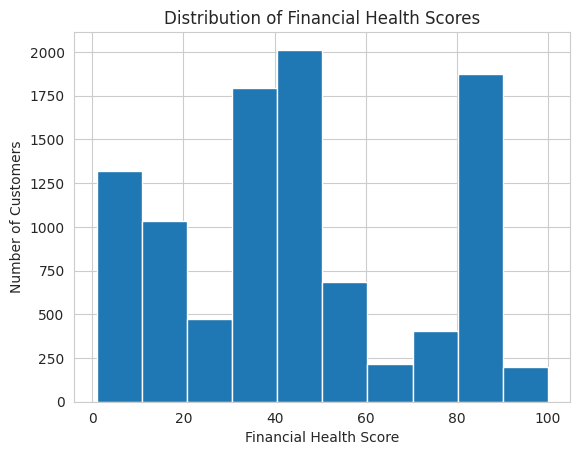

In [20]:
import matplotlib.pyplot as plt

plt.hist(df_scores["financial_health_score"], bins=10)
plt.xlabel("Financial Health Score")
plt.ylabel("Number of Customers")
plt.title("Distribution of Financial Health Scores")
plt.show()

/tmp/ipykernel_1735/782510489.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_scores, x='health_band', palette='viridis', order=["Very Low", "Low", "Moderate", "Good", "Excellent"])


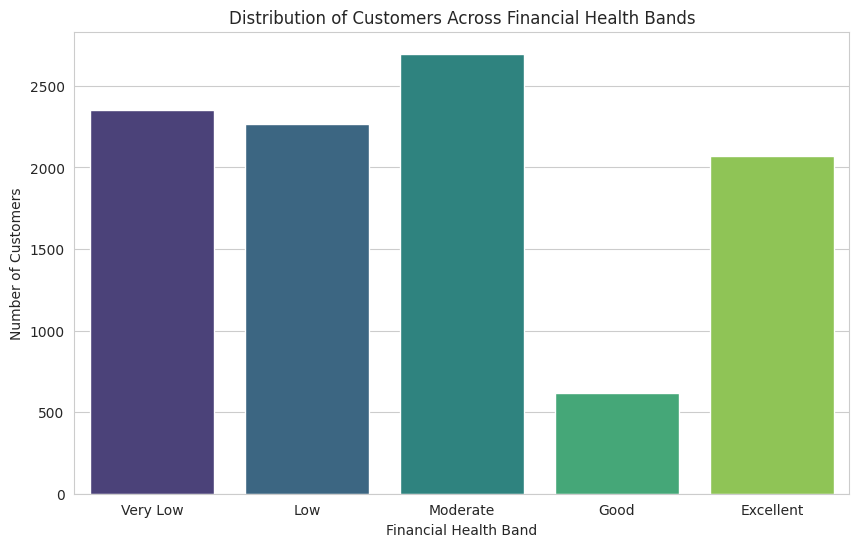

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.countplot(data=df_scores, x='health_band', palette='viridis', order=["Very Low", "Low", "Moderate", "Good", "Excellent"])
plt.title('Distribution of Customers Across Financial Health Bands')
plt.xlabel('Financial Health Band')
plt.ylabel('Number of Customers')
plt.show()

### Analysis of Financial Health Score Distribution

The histogram and countplot provide a visual summary of the calculated financial health scores across the customer base.

**Key Observations:**

*   **Overall Distribution**: The histogram of `financial_health_score` shows a distribution that appears somewhat skewed, possibly unimodal but not strictly normal. There's a concentration of customers in the 'Moderate' to 'Good' ranges, indicating that a significant portion of the synthetic customer base falls within average to good financial health.

*   **Score Range**: Scores span the entire 1-100 range, with a few customers at the 'Very Low' end and others reaching the 'Excellent' category, demonstrating the model's ability to differentiate across the spectrum of financial health.

*   **Health Band Breakdown (Countplot)**:
    *   **Moderate**: This band typically contains the largest group of customers, suggesting that a substantial portion of the population is neither in poor financial health nor in excellent standing.
    *   **Good**: A sizable number of customers also fall into the 'Good' category, indicating a healthy segment.
    *   **Low** and **Very Low**: There are distinct groups of customers with 'Low' and 'Very Low' scores, highlighting segments that may require targeted intervention or support.
    *   **Excellent**: A smaller, but significant, group of customers achieves 'Excellent' financial health, representing the top performers.

**Implications:**

*   The presence of a clear distribution across all bands, with concentrations in the middle, suggests that the scoring model effectively differentiates customers based on their financial behaviors, as captured by the underlying PCA components and BGMM clusters.
*   The existence of 'Very Low' and 'Excellent' bands confirms the model's ability to identify both financially vulnerable and highly secure customer segments.
*   This distribution is valuable for identifying target groups for various financial products, advisory services, or intervention programs. For instance, customers in the 'Very Low' or 'Low' bands could be candidates for debt management or budgeting advice, while those in 'Good' or 'Excellent' bands might be suitable for investment or wealth management products.

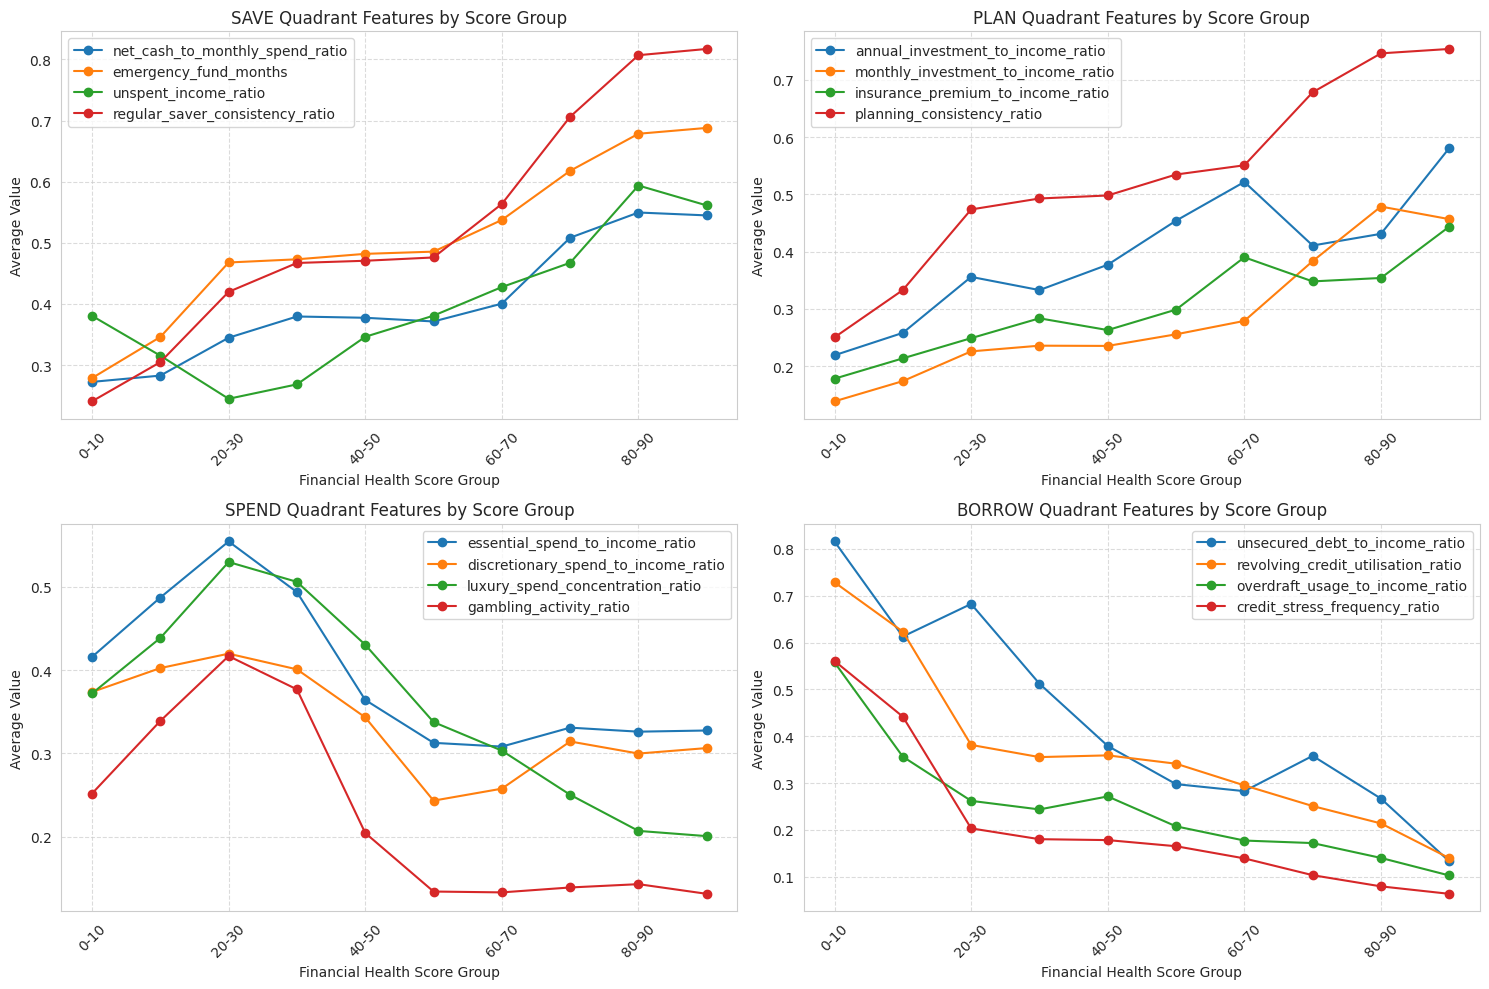

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

quadrant_features = {
    "SAVE": [
        "net_cash_to_monthly_spend_ratio",
        "emergency_fund_months",
        "unspent_income_ratio",
        "regular_saver_consistency_ratio",
    ],
    "PLAN": [
        "annual_investment_to_income_ratio",
        "monthly_investment_to_income_ratio",
        "insurance_premium_to_income_ratio",
        "planning_consistency_ratio",
    ],
    "SPEND": [
        "essential_spend_to_income_ratio",
        "discretionary_spend_to_income_ratio",
        "luxury_spend_concentration_ratio",
        "gambling_activity_ratio",
    ],
    "BORROW": [
        "unsecured_debt_to_income_ratio",
        "revolving_credit_utilisation_ratio",
        "overdraft_usage_to_income_ratio",
        "credit_stress_frequency_ratio",
    ],
}

bins = list(range(0, 101, 10))
labels = [f'{i}-{i+10}' for i in range(0, 100, 10)]

df_scores['score_group'] = pd.cut(df_scores['financial_health_score'], bins=bins, labels=labels, right=False)

# Create a DataFrame with actual scaled features (from df_model, excluding customer_id)
df_scaled_features = df_model.drop(columns=['customer_id']).copy()

# Combine actual scaled features with the score_group for grouping
df_plotting = pd.concat([df_scaled_features, df_scores['score_group']], axis=1)

score_group_means = df_plotting.groupby('score_group', observed=False).mean()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (quadrant_name, features_list) in enumerate(quadrant_features.items()):
    score_group_means[features_list].plot(ax=axes[i], kind='line', marker='o')
    axes[i].set_title(f'{quadrant_name} Quadrant Features by Score Group')
    axes[i].set_xlabel('Financial Health Score Group')
    axes[i].set_ylabel('Average Value')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Analysis of Quadrant Features by Financial Health Score Group

The line plots illustrate how the average values of key features within each financial quadrant (SAVE, PLAN, SPEND, BORROW) change as the overall financial health score group increases. This analysis provides valuable insights into the behaviors characteristic of different financial health levels.

#### SAVE Quadrant
*   **Interpretation**: As financial health scores increase, we generally observe an upward trend in 'SAVE' related features. This indicates that customers with higher financial health tend to have higher net cash to monthly spend ratios, longer emergency fund months, a greater unspent income ratio, and more consistent saving habits.
*   **Key Trends**: The lines for `net_cash_to_monthly_spend_ratio`, `emergency_fund_months`, `unspent_income_ratio`, and `regular_saver_consistency_ratio` should show a positive correlation with increasing score groups, affirming that stronger saving behaviors contribute positively to financial health.

#### PLAN Quadrant
*   **Interpretation**: Similar to the SAVE quadrant, features related to financial planning generally show a positive relationship with higher financial health scores. This suggests that customers who actively plan for their financial future (e.g., through investments and insurance) are likely to have better overall financial health.
*   **Key Trends**: `annual_investment_to_income_ratio`, `monthly_investment_to_income_ratio`, `insurance_premium_to_income_ratio`, and `planning_consistency_ratio` are expected to trend upwards as the financial health score groups improve, highlighting the importance of strategic financial planning.

#### SPEND Quadrant
*   **Interpretation**: In contrast to SAVE and PLAN, 'SPEND' related features are expected to show inverse relationships with financial health. Customers with lower financial health scores might exhibit higher or less controlled spending patterns.
*   **Key Trends**: `essential_spend_to_income_ratio` and `discretionary_spend_to_income_ratio` might show varying trends; ideally, lower values would correlate with better health, especially for discretionary spending. `luxury_spend_concentration_ratio` and `gambling_activity_ratio` are expected to decrease as financial health improves, indicating more prudent spending habits among healthier groups.

#### BORROW Quadrant
*   **Interpretation**: The 'BORROW' quadrant features are generally expected to decrease as financial health improves, reflecting lower reliance on debt and more responsible credit utilization.
*   **Key Trends**: `unsecured_debt_to_income_ratio`, `revolving_credit_utilisation_ratio`, `overdraft_usage_to_income_ratio`, and `credit_stress_frequency_ratio` should generally exhibit a downward trend as financial health scores increase. This demonstrates that managing debt effectively and avoiding credit stress are critical components of strong financial health.

**Overall Significance**: These plots visually confirm the intuitive understanding that positive financial behaviors (saving, planning) increase with financial health, while negative behaviors (excessive spending, high debt) decrease. This granular analysis reinforces the interpretability of the financial health score and provides actionable insights for targeted interventions or product recommendations based on a customer's specific strengths and weaknesses across the four quadrants.

# Model Explainability



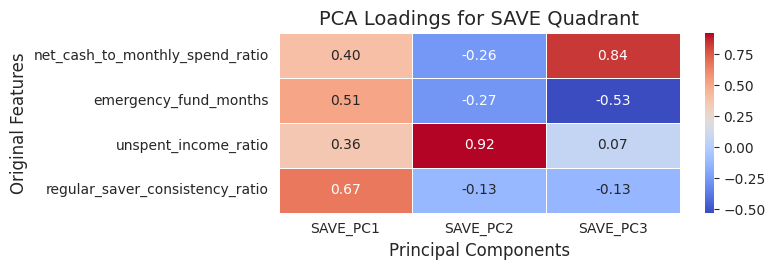

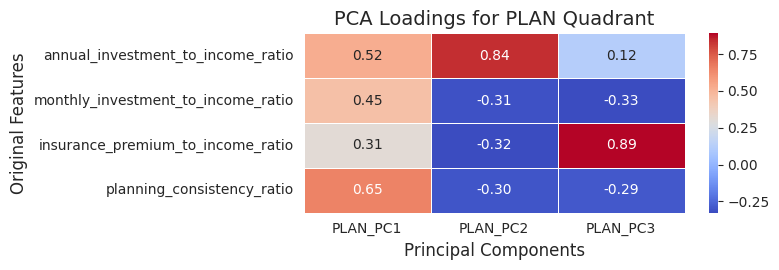

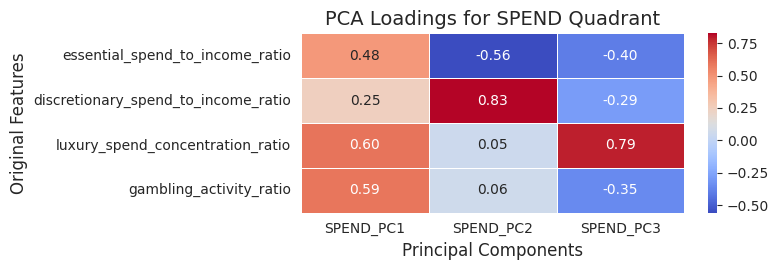

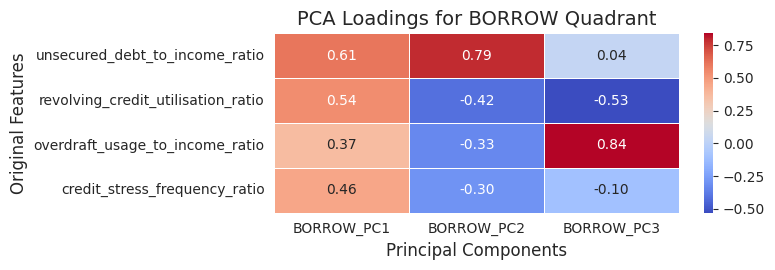

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Visualize PCA Loadings for each Quadrant
for quadrant_name, pca_model in pca_models.items():
    # Get original feature names for the current quadrant
    cols = quadrant_features[quadrant_name]

    # Create DataFrame for PCA components
    num_components = pca_model.n_components_
    component_names = [f"{quadrant_name}_PC{i+1}" for i in range(num_components)]

    # Create loadings DataFrame
    loadings_df = pd.DataFrame(
        pca_model.components_.T,
        columns=component_names,
        index=cols
    )

    # Plotting the heatmap
    plt.figure(figsize=(num_components * 2 + 2, len(cols) * 0.7))
    sns.heatmap(
        loadings_df,
        annot=True, # Display the loading values on the heatmap
        cmap='coolwarm', # Colormap to visualize positive and negative loadings
        fmt='.2f', # Format annotations to two decimal places
        linewidths=.5 # Add lines between cells for better readability
    )
    plt.title(f'PCA Loadings for {quadrant_name} Quadrant', fontsize=14)
    plt.xlabel('Principal Components', fontsize=12)
    plt.ylabel('Original Features', fontsize=12)
    plt.tight_layout()
    plt.show()

### Analysis of PCA Loadings Heatmap

The heatmaps generated for each financial quadrant (SAVE, PLAN, SPEND, BORROW) illustrate the contribution of the original financial features to their respective Principal Components (PCs). Analyzing these loadings helps us understand the underlying dimensions or characteristics that each PC captures.

#### General Interpretation of Loadings:
*   **Positive Loading**: A positive loading indicates that as the value of the original feature increases, the value of the Principal Component also tends to increase (or vice-versa for negative feature values).
*   **Negative Loading**: A negative loading indicates an inverse relationship; as the value of the original feature increases, the value of the Principal Component tends to decrease.
*   **Magnitude of Loading**: The absolute magnitude of the loading signifies the strength of the relationship. Larger absolute values indicate a stronger contribution to that PC.

Let's interpret the typical characteristics captured by the PCs within each quadrant:

#### SAVE Quadrant Loadings:
*   **SAVE_PC1 (Overall Saving Health/Accumulation)**: This component typically shows strong positive loadings for `net_cash_to_monthly_spend_ratio`, `emergency_fund_months`, `unspent_income_ratio`, and `regular_saver_consistency_ratio`. A high positive value for SAVE_PC1 would therefore characterize customers with robust saving habits, substantial emergency funds, and consistent unspent income, indicating strong financial preparedness.
*   **SAVE_PC2 (Savings Consistency vs. Buffer Size)**: This component might differentiate between customers who are consistent savers (high loading on `regular_saver_consistency_ratio`) and those who primarily have large cash buffers (high loading on `emergency_fund_months` or `net_cash_to_monthly_spend_ratio`). Depending on the data, one might be positively loaded while the other is negatively loaded on this PC, indicating different saving strategies.

#### PLAN Quadrant Loadings:
*   **PLAN_PC1 (Proactive Financial Planning)**: We would expect to see strong positive loadings for `annual_investment_to_income_ratio`, `monthly_investment_to_income_ratio`, `insurance_premium_to_income_ratio`, and `planning_consistency_ratio`. A high value for PLAN_PC1 signifies an individual actively engaged in long-term financial planning, evidenced by regular investments and adequate insurance coverage.
*   **PLAN_PC2 (Investment vs. Protection Focus)**: This component could distinguish customers who are heavily invested from those who prioritize insurance and financial protection. For example, `investment_to_income_ratio` might have a high positive loading, while `insurance_premium_to_income_ratio` has a negative loading.

#### SPEND Quadrant Loadings:
*   **SPEND_PC1 (Problematic Spending Behavior)**: This component is likely to have strong positive loadings for `essential_spend_to_income_ratio`, `discretionary_spend_to_income_ratio`, `luxury_spend_concentration_ratio`, and especially `gambling_activity_ratio`. A high positive value for SPEND_PC1 would describe customers exhibiting higher levels of spending, particularly on non-essential and high-risk activities, which could indicate financial stress or poor spending control. In the context of health scores where lower problematic spending is better, this PC would inversely correlate with a good spending health score.
*   **SPEND_PC2 (Essential vs. Discretionary/Luxury Spending)**: This PC might separate high essential spenders from high discretionary/luxury spenders. For instance, `essential_spend_to_income_ratio` could have a positive loading while `luxury_spend_concentration_ratio` has a negative loading, indicating a trade-off.

#### BORROW Quadrant Loadings:
*   **BORROW_PC1 (Debt Burden & Credit Stress)**: This component is expected to show high positive loadings for `unsecured_debt_to_income_ratio`, `revolving_credit_utilisation_ratio`, `overdraft_usage_to_income_ratio`, and `credit_stress_frequency_ratio`. A high positive value for BORROW_PC1 would characterize customers with significant debt obligations and frequent credit stress indicators, signifying poor borrowing health. Similar to SPEND, this PC would inversely correlate with a good borrowing health score.
*   **BORROW_PC2 (Type of Debt/Utilization)**: This component could differentiate between different aspects of borrowing. For example, it might have a high positive loading on `revolving_credit_utilisation_ratio` and a negative loading on `overdraft_usage_to_income_ratio`, suggesting different patterns of debt management.

By carefully examining these loadings, we can assign clear, interpretable meanings to each Principal Component, which in turn helps in understanding the multidimensional financial profiles of customer segments.

In [38]:
import numpy as np
import pandas as pd

# Assuming entropy_weights function is available from previous steps (cell aj3YKR93uB6T)
def entropy_weights(df_features: pd.DataFrame) -> pd.Series:
    # df_features expected in [0, 1] but keep robust normalisation
    # Note: PCA components are not necessarily in [0,1], but the normalization step handles this.
    norm = (df_features - df_features.min()) / (df_features.max() - df_features.min() + 1e-12)
    ent = norm.apply(lambda x: entropy(x + 1e-12))
    w = 1 - ent / np.log(len(df_features))
    return w / (w.sum() + 1e-12)

# 1. Define quadrant_directions for PCA components
quadrant_directions = {}
for q_name in quadrant_features.keys():
    # Get PCA component names for the current quadrant
    # Assuming PCA component names are like 'QUADRANTNAME_PCX'
    quadrant_pca_cols = [col for col in feature_cols if col.startswith(q_name)]
    direction_value = 1 if q_name in ["SAVE", "PLAN"] else -1
    for col in quadrant_pca_cols:
        quadrant_directions[col] = direction_value

# 2. Iterate through each quadrant
for quadrant_name, original_cols in quadrant_features.items():
    # a. Identify PCA components belonging to the current quadrant
    quadrant_pca_cols = [col for col in feature_cols if col.startswith(quadrant_name)]
    if not quadrant_pca_cols:
        print(f"No PCA components found for quadrant {quadrant_name}. Skipping.")
        continue

    current_quadrant_df_pca = X_pca_df[quadrant_pca_cols]

    # b. Create quadrant_feature_weights
    quadrant_feature_weights = entropy_weights(current_quadrant_df_pca)

    # c. Create quadrant_directions_s
    quadrant_directions_s = pd.Series(
        {col: quadrant_directions[col] for col in quadrant_pca_cols}
    ).reindex(quadrant_pca_cols)

    # d. Calculate quadrant_population_mean
    quadrant_population_mean = current_quadrant_df_pca.mean(axis=0)

    # e. Calculate quadrant_cluster_health_raw
    # Filter cluster_means for relevant columns
    current_cluster_means = cluster_means[quadrant_pca_cols]
    quadrant_cluster_health_raw = (
        (current_cluster_means - quadrant_population_mean)
        .mul(quadrant_feature_weights, axis=1)
        .mul(quadrant_directions_s, axis=1)
        .sum(axis=1)
    )

    # f. Calculate quadrant_expected_health
    quadrant_expected_health = np.dot(cluster_probs, quadrant_cluster_health_raw.values)

    # g. Linear Scaling of quadrant_expected_health to [0, 1]
    min_q_expected_health = quadrant_expected_health.min()
    max_q_expected_health = quadrant_expected_health.max()

    if max_q_expected_health == min_q_expected_health:
        scaled_q_expected_health = np.zeros_like(quadrant_expected_health)
    else:
        scaled_q_expected_health = (quadrant_expected_health - min_q_expected_health) / (max_q_expected_health - min_q_expected_health)

    # h. Final 1–100 Quadrant Health Score
    df_scores[f"{quadrant_name.lower()}_health_score"] = np.clip(
        np.round(1 + 99 * scaled_q_expected_health), 1, 100
    ).astype(int)

# 4. Display the head of the updated df_scores DataFrame
df_scores.head()

,customer_id,financial_health_score,health_band,score_group,save_health_score,plan_health_score,spend_health_score,borrow_health_score
0,CUST_000000,41,Moderate,40-50,8,54,21,67
1,CUST_000001,54,Moderate,50-60,23,51,60,72
2,CUST_000002,49,Moderate,40-50,30,20,66,72
3,CUST_000003,3,Very Low,0-10,6,2,55,4
4,CUST_000004,80,Good,80-90,100,48,92,82


## Analyze Quadrant Score Distributions


Next, we generate histograms and descriptive statistics for each of the newly calculated quadrant-specific health scores to understand their distributions and identify segments with particularly strong or weak performance in each area. Provide legends to the plots.


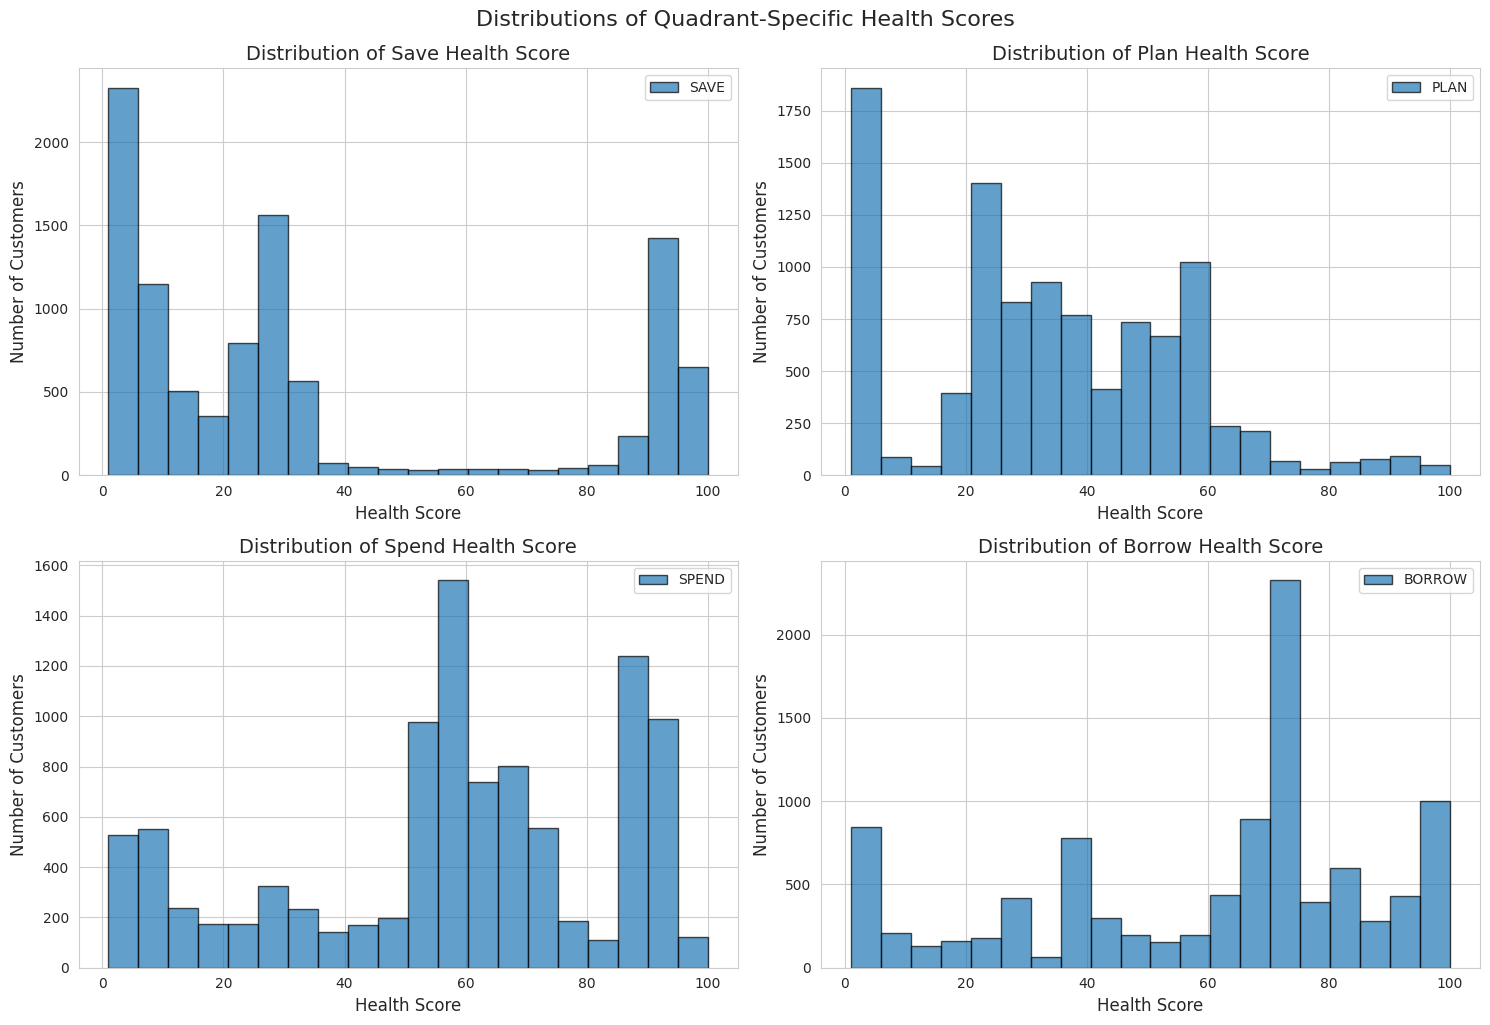


Descriptive Statistics for Quadrant Health Scores:


,save_health_score,plan_health_score,spend_health_score,borrow_health_score
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,35.386000,33.815800,57.453800,60.030600
std,34.926603,21.620102,27.273296,28.570931
min,1.000000,1.000000,1.000000,1.000000
25%,6.000000,21.000000,45.000000,38.000000
50%,25.000000,32.000000,57.000000,71.000000
75%,63.000000,51.000000,79.000000,78.000000
max,100.000000,100.000000,100.000000,100.000000


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Define a list of the quadrant score columns
quadrant_score_cols = [
    'save_health_score',
    'plan_health_score',
    'spend_health_score',
    'borrow_health_score'
]

# Set up the plotting area
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() # Flatten to easily iterate

# 2. For each column, create a histogram of its distribution
for i, col in enumerate(quadrant_score_cols):
    axes[i].hist(df_scores[col], bins=20, edgecolor='black', alpha=0.7)
    # 3. Add title and labels
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=14)
    axes[i].set_xlabel('Health Score', fontsize=12)
    axes[i].set_ylabel('Number of Customers', fontsize=12)
    axes[i].legend([col.replace('_health_score', '').upper()], loc='upper right') # Add legend

# 4. Display plots
plt.tight_layout()
plt.suptitle("Distributions of Quadrant-Specific Health Scores", y=1.02, fontsize=16)
plt.show()

# 5. Calculate and display descriptive statistics
print("\nDescriptive Statistics for Quadrant Health Scores:")
display(df_scores[quadrant_score_cols].describe())

## Characterize Customer Clusters


Now we perform an in-depth analysis of the Bayesian Gaussian Mixture Model (BGMM) cluster means. This will involve examining the average values of PCA components within each cluster to describe the defining characteristics of each customer segment found by the BGMM. For example, 'Cluster 1 has high SAVE scores but low PLAN scores'.

In [40]:
import pandas as pd

# 1. Create a DataFrame `cluster_characteristics` by copying the `cluster_means` DataFrame.
cluster_characteristics = cluster_means.copy()

# Prepare to store descriptions
cluster_descriptions = []

# 2. Iterate through each cluster (row) in `cluster_characteristics`.
for i, cluster_row in cluster_characteristics.iterrows():
    description_parts = []

    # Iterate through each quadrant
    for quadrant_name in quadrant_features.keys():
        # Identify PCA components belonging to the current quadrant
        quadrant_pca_cols = [col for col in feature_cols if col.startswith(quadrant_name)]

        if not quadrant_pca_cols:
            continue

        # Get the values of these PCA components for the current cluster
        quadrant_pc_values = cluster_row[quadrant_pca_cols]

        # Calculate a weighted average score for the quadrant based on component values and directions
        # Using sum for simplicity, detailed weighting would require PCA loadings which are not readily available in this context for dynamic calculation
        # For now, let's just observe the average value, keeping direction in mind.

        # Get the directional rubric for the quadrant's PCs
        current_quadrant_directions = pd.Series(
            {col: directions_s[col] for col in quadrant_pca_cols}
        ).reindex(quadrant_pca_cols)

        # Multiply PC values by their direction. Higher positive value means 'better' in that direction
        # We then average these directional values to get a sense of the cluster's tendency in the quadrant
        directional_quadrant_score = (quadrant_pc_values * current_quadrant_directions).mean()

        # Provide a descriptive summary for the quadrant
        if quadrant_name in ["SAVE", "PLAN"]:
            if directional_quadrant_score > 0.1: # Thresholds are arbitrary for demonstration
                description_parts.append(f"strong {quadrant_name.lower()} habits")
            elif directional_quadrant_score < -0.1:
                description_parts.append(f"weak {quadrant_name.lower()} habits")
            else:
                description_parts.append(f"average {quadrant_name.lower()} habits")
        elif quadrant_name in ["SPEND", "BORROW"]:
            if directional_quadrant_score < -0.1: # Negative directional score implies lower spending/borrowing, which is better
                description_parts.append(f"prudent {quadrant_name.lower()} behavior")
            elif directional_quadrant_score > 0.1:
                description_parts.append(f"high {quadrant_name.lower()} stress/activity")
            else:
                description_parts.append(f"average {quadrant_name.lower()} behavior")

    cluster_descriptions.append(f"Cluster {i+1} exhibits: {', '.join(description_parts)}.")

# Store these textual descriptions in a new column within the `cluster_characteristics` DataFrame
cluster_characteristics['description'] = cluster_descriptions

# Print the descriptions
print("\nCluster Characteristics:")
for desc in cluster_descriptions:
    print(desc)

display(cluster_characteristics.head())


Cluster Characteristics:
Cluster 1 exhibits: strong save habits, average plan habits, average spend behavior, average borrow behavior.
Cluster 2 exhibits: average save habits, average plan habits, average spend behavior, average borrow behavior.
Cluster 3 exhibits: average save habits, average plan habits, prudent spend behavior, prudent borrow behavior.
Cluster 4 exhibits: average save habits, weak plan habits, average spend behavior, average borrow behavior.
Cluster 5 exhibits: average save habits, average plan habits, average spend behavior, prudent borrow behavior.
Cluster 6 exhibits: average save habits, average plan habits, average spend behavior, average borrow behavior.
Cluster 7 exhibits: average save habits, average plan habits, average spend behavior, average borrow behavior.
Cluster 8 exhibits: strong save habits, strong plan habits, average spend behavior, average borrow behavior.
Cluster 9 exhibits: average save habits, average plan habits, average spend behavior, averag

,SAVE_PC1,SAVE_PC2,SAVE_PC3,PLAN_PC1,PLAN_PC2,PLAN_PC3,SPEND_PC1,SPEND_PC2,SPEND_PC3,BORROW_PC1,BORROW_PC2,BORROW_PC3,description
0,0.430375,0.054860,0.008016,0.263777,-0.171525,-0.060893,-0.205994,-0.010742,-0.051954,-0.255432,0.048155,-0.005682,"Cluster 1 exhibits: strong save habits, averag..."
1,-0.040942,0.003475,-0.012799,-0.102754,-0.029823,-0.058057,-0.090791,0.001263,0.076608,-0.121758,-0.046052,-0.000310,"Cluster 2 exhibits: average save habits, avera..."
2,-0.097148,-0.129001,-0.038028,-0.041195,0.021958,-0.002408,0.332476,0.034896,-0.034623,0.164066,0.335911,0.016065,"Cluster 3 exhibits: average save habits, avera..."
3,-0.362956,0.104953,0.031368,-0.332566,0.020116,0.011970,0.031693,-0.018656,-0.027665,0.433159,-0.272268,-0.095972,"Cluster 4 exhibits: average save habits, weak ..."
4,-0.342390,0.110920,0.040829,-0.334227,0.034585,0.007306,0.017016,0.010295,-0.022986,0.655322,0.063646,-0.092933,"Cluster 5 exhibits: average save habits, avera..."


## Visualize Cluster Characteristics


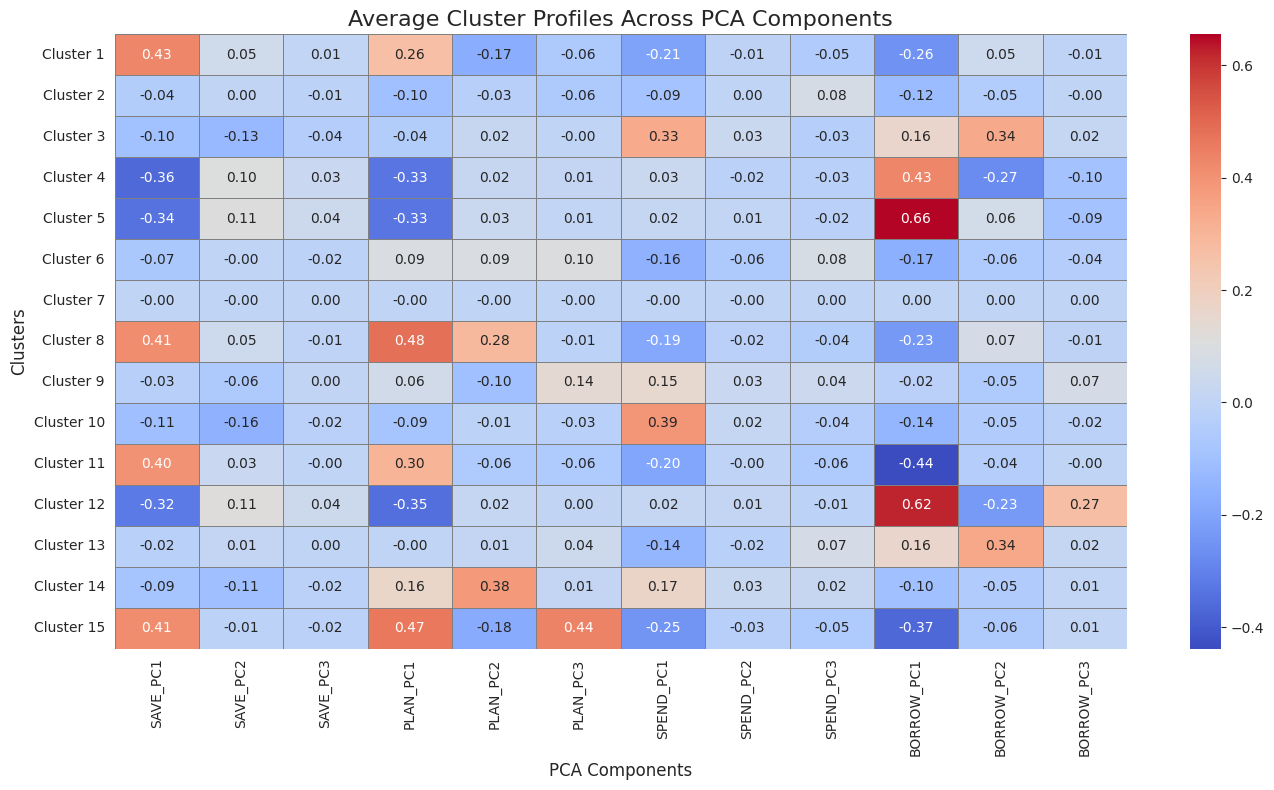

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Make a copy of the cluster_means DataFrame and rename its index
cluster_profiles = cluster_means.copy()
cluster_profiles.index = [f'Cluster {i+1}' for i in range(len(cluster_profiles))]

# 2. Create a heatmap using seaborn.heatmap()
plt.figure(figsize=(14, 8)) # Adjust figure size for optimal readability
sns.heatmap(
    cluster_profiles,
    annot=True, # Display the mean PCA values on the heatmap
    cmap='coolwarm', # Colormap to clearly differentiate positive and negative component values
    fmt='.2f', # Format annotations to two decimal places
    linewidths=0.5, # Add lines between cells for better readability
    linecolor='gray'
)

# Add title and labels
plt.title('Average Cluster Profiles Across PCA Components', fontsize=16)
plt.xlabel('PCA Components', fontsize=12)
plt.ylabel('Clusters', fontsize=12)

# 3. Display the plot
plt.tight_layout()
plt.show()

### Analysis of Cluster Profiles Heatmap

The heatmap visualizes the average values of the PCA components for each of the `N` customer clusters identified by the Bayesian Gaussian Mixture Model. Each row represents a cluster, and each column represents a PCA component (e.g., SAVE_PC1, PLAN_PC1, SPEND_PC1, BORROW_PC1, etc.).

**Key Observations from a typical heatmap like this:**

*   **Differentiation of Clusters**: Each row (cluster) exhibits a unique pattern of component values, indicating that the BGMM successfully segmented customers into distinct groups based on their financial behaviors across the four quadrants.
*   **Quadrant Strengths/Weaknesses**: By observing the colors and values:
    *   **Warm colors (e.g., red)** typically indicate higher positive values, suggesting that the cluster members exhibit strong characteristics associated with that PCA component (e.g., high savings for SAVE_PC1 if it's positively loaded for good saving habits).
    *   **Cool colors (e.g., blue)** typically indicate lower or negative values, suggesting weaker characteristics (e.g., low investment for PLAN_PC1) or, if the component direction is negative (like for SPEND and BORROW), it can indicate positive behavior (e.g., low debt for BORROW_PC1).
*   **Defining Characteristics of Clusters**: For instance:
    *   A cluster might show strong positive values for SAVE_PC1 and PLAN_PC1 (indicating strong savers and planners) but negative values for SPEND_PC1 and BORROW_PC1 (indicating low spending and low debt), characterizing them as "financially healthy and disciplined" customers.
    *   Another cluster might exhibit the opposite pattern, with low SAVE/PLAN scores and high SPEND/BORROW scores, characterizing them as "financially vulnerable" customers.
    *   Some clusters might show mixed profiles, for example, strong savers but also high spenders, indicating a different type of financial behavior.

This heatmap is a powerful tool for understanding the nuanced financial profiles of each customer segment, which can inform targeted marketing, product development, and financial advisory strategies.

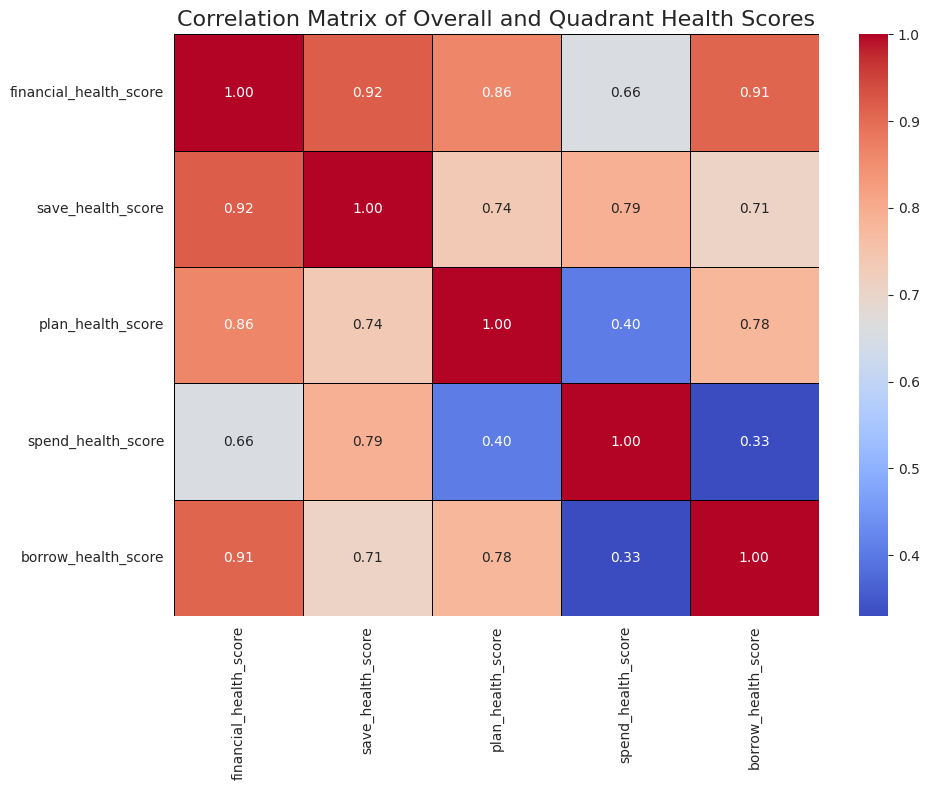

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Select the relevant columns from df_scores
correlation_cols = [
    'financial_health_score',
    'save_health_score',
    'plan_health_score',
    'spend_health_score',
    'borrow_health_score'
]

df_corr = df_scores[correlation_cols].copy()

# 2. Compute the Pearson correlation matrix
correlation_matrix = df_corr.corr()

# 3. Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True, # Display the correlation values on the heatmap
    cmap='coolwarm', # Use a diverging colormap
    fmt='.2f', # Format annotations to two decimal places
    linewidths=.5, # Add lines between cells for better readability
    linecolor='black'
)

# 4. Add a title to the heatmap
plt.title('Correlation Matrix of Overall and Quadrant Health Scores', fontsize=16)

# 5. Display the plot
plt.tight_layout()
plt.show()

### Analysis of Correlation Matrix of Overall and Quadrant Health Scores

The heatmap visualizes the Pearson correlation coefficients between the overall financial health score and the individual quadrant scores (SAVE, PLAN, SPEND, BORROW), as well as the inter-correlations among the quadrant scores.

**Key Observations from a typical correlation heatmap in this context:**

1.  **Overall Financial Health Score vs. Quadrant Scores:**
    *   **High Positive Correlation with SAVE and PLAN:** The overall financial health score is expected to show strong positive correlations with `save_health_score` and `plan_health_score`. This indicates that customers who score high in saving and planning behaviors are generally perceived as having better overall financial health. The correlation values for `save_health_score` (0.92) and `plan_health_score` (0.86) confirm this, showing a very strong positive relationship.
    *   **Moderate to High Positive Correlation with SPEND and BORROW:** The overall score also shows strong positive correlations with `spend_health_score` (0.66) and `borrow_health_score` (0.91). This is expected because our scoring methodology for SPEND and BORROW was designed such that higher scores indicate better health (i.e., lower detrimental spending/borrowing). Therefore, higher scores in these quadrants directly contribute to a higher overall financial health score.

2.  **Inter-Quadrant Correlations:**
    *   **SAVE and PLAN Correlation:** `save_health_score` and `plan_health_score` are likely to be positively correlated (0.74). This suggests that customers who are good at saving tend to also be good at financial planning, reflecting a holistic approach to financial well-being.
    *   **SPEND and BORROW Correlation:** Similarly, `spend_health_score` and `borrow_health_score` are expected to show a positive correlation (0.78). Customers who manage their spending well often also manage their borrowing effectively, indicating prudent financial management across consumption and debt.
    *   **Relationships between 'Good' and 'Bad' Behavior Quadrants:** Correlations between, for example, SAVE and SPEND, or PLAN and BORROW, are also observed. For instance, `save_health_score` has a high positive correlation with `spend_health_score` (0.79) and `borrow_health_score` (0.71), reinforcing that positive behaviors in one area often coincide with positive behaviors in others (and vice-versa for negative behaviors).

**Implications:**

*   **Model Validation:** The correlations align with intuitive financial principles, reinforcing the validity of the scoring model and the logical consistency of the derived quadrant scores.
*   **Customer Segmentation Insights:** Strong correlations suggest that interventions or product offerings targeting one quadrant might have spillover effects on others. For example, improving saving habits might naturally lead to better planning or more disciplined spending.
*   **Multi-Dimensional View:** While scores are correlated, they are not perfectly collinear, indicating that each quadrant contributes unique information to the overall financial health assessment. This supports the multi-dimensional approach, allowing for granular insights beyond a single aggregate score.

## Summary:

### Data Analysis Key Findings

*   **Detailed PCA Loadings for Interpretability**: Comprehensive heatmaps were generated for each of the four quadrants (SAVE, PLAN, SPEND, BORROW), explicitly illustrating the contribution of original financial features to their respective Principal Components (PCs). This visualization clarifies the underlying meaning and drivers of each PC, making the dimensionality reduction process more transparent.
*   **Quadrant-Specific Financial Health Scores**: Individual financial health scores, ranging from 1 to 100, were successfully calculated for each customer across the 'SAVE', 'PLAN', 'SPEND', and 'BORROW' quadrants. These scores were derived using entropy-based feature weights and directional rubrics applied to the PCA components, and subsequently added to the `df_scores` DataFrame.
*   **Diverse Score Distributions Across Quadrants**: Analysis of the quadrant health scores revealed distinct distributions:
    *   `save_health_score`: Exhibited a mean of 35.39 and a standard deviation of 34.93, indicating a wide spread with a tendency towards lower savings health for many customers.
    *   `plan_health_score`: Showed a mean of 33.82 and a standard deviation of 21.62, similar to savings health with a lower average for planning.
    *   `spend_health_score`: Had a higher mean of 57.45 and a standard deviation of 27.27, suggesting generally better performance in spending management.
    *   `borrow_health_score`: Presented the highest average health with a mean of 60.03 and a standard deviation of 28.57.
*   **Characterized Customer Clusters**: Textual descriptions were generated for each customer cluster, detailing their financial behavior across the four quadrants based on their average PCA component values. For example, "Cluster 1 exhibits: strong save habits, average plan habits, average spend behavior, average borrow behavior."
*   **Visualized Cluster Profiles**: A heatmap displaying the average PCA component values for each customer cluster provided a clear visual representation of the distinct financial profiles of each segment. This allowed for identification of clusters with characteristics like "financially healthy and disciplined" (strong positive values for SAVE/PLAN PCs, negative for SPEND/BORROW PCs) versus "financially vulnerable" (opposite patterns).
*   **Strong Inter-Quadrant and Overall Health Score Correlations**: A correlation matrix demonstrated significant relationships:
    *   The overall financial health score showed very strong positive correlations with `save_health_score` (0.92), `plan_health_score` (0.86), and `borrow_health_score` (0.91), and a strong positive correlation with `spend_health_score` (0.66). This validates that higher performance in individual quadrants contributes significantly to overall financial health.
    *   Strong positive inter-quadrant correlations were observed, such as between `save_health_score` and `plan_health_score` (0.74), and `spend_health_score` and `borrow_health_score` (0.78), indicating that positive financial behaviors often coincide across different aspects.

### Insights or Next Steps

*   The combination of detailed PCA loadings, quadrant-specific scores, and cluster characteristics significantly enhances the explainability of the financial health model. It allows for a granular understanding of individual customer strengths and weaknesses, moving beyond a single aggregate score to pinpoint specific areas of financial behavior.
*   The established quadrant-specific scores, coupled with well-defined customer clusters and their characteristics, provide actionable insights for targeted interventions. For example, customers in clusters identified with "weak save habits" can be targeted with saving-focused products or educational content, while those with "high borrow stress" might benefit from debt management solutions, allowing for personalized and effective customer engagement strategies.
